<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Model_finetuning_mistral_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch transformers peft trl

In [2]:
!pip install bitsandbytes

In [3]:
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# Hyperparameter configurations

Model that is fine tuned is mistral AI. Mistral AI is known for beeing efficient and powerful. Other model to consider aree Llama-3 (computationally expensive), Phi-3

In [4]:
# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
MODEL_ID = "mistralai/Mistral-7B-v0.1"  # Replace with your choice (e.g., Llama-3, Phi-3)
OUTPUT_DIR = "./fine_tuned_llm"

# LoRA Hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# Training Hyperparameters
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 2e-4
MAX_STEPS = 100  # Adjust based on dataset size (or use num_train_epochs)

###LoRA Hyperparameters (for QLoRA fine-tuning):


LORA_R = 16 (Rank r): This is one of the most crucial LoRA parameters. It determines the rank of the low-rank matrices that are added to the pre-trained model's weight matrices. A higher r allows for more expressiveness and capacity to learn new information, but also increases the number of trainable parameters and VRAM usage. A lower r means fewer trainable parameters, making the fine-tuning more efficient but potentially less effective at capturing complex new patterns.

LORA_ALPHA = 32 (α): This parameter scales the learned low-rank updates. It's often set to 2 * LORA_R or a similar multiple. A higher alpha means the LoRA layers have a stronger influence on the original weights. It essentially controls the magnitude of the updates applied by the LoRA adapters.

LORA_DROPOUT = 0.05: This is a standard dropout rate applied to the LoRA layers during training. Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting by encouraging the model to learn more robust features.

TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]: This specifies which parts (modules) of the pre-trained transformer model will have LoRA layers attached to them. In Large Language Models, q_proj, k_proj, v_proj (query, key, and value projection layers in attention mechanisms) and o_proj (output projection) are common targets. gate_proj, up_proj, down_proj refer to the feed-forward network's layers.

By selectively applying LoRA to these critical modules, you can efficiently fine-tune the model without modifying all its original weights.

###Training Hyperparameters:


BATCH_SIZE = 4 (per_device_train_batch_size): This is the number of training examples processed at once on each GPU. Smaller batch sizes often lead to better generalization but longer training times. For QLoRA, which is memory-efficient, you can often use larger batch sizes than full fine-tuning.

GRADIENT_ACCUMULATION_STEPS = 4: When memory is a constraint (even with QLoRA), you can simulate a larger effective batch size by accumulating gradients over several smaller batches. Here, an effective batch size of BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS = 4 * 4 = 16 is used. The model weights are updated only after processing GRADIENT_ACCUMULATION_STEPS batches.

LEARNING_RATE = 2e-4: This determines the step size at each iteration while moving towards a minimum of the loss function. It's a critical hyperparameter; too high, and the model might overshoot the minimum; too low, and training could be very slow or get stuck in a local minimum. For QLoRA, a slightly lower learning rate than full fine-tuning is often recommended.

MAX_STEPS = 100: This defines the total number of update steps (batches after gradient accumulation) the trainer will perform during the fine-tuning process. You mentioned adjusting this based on dataset size or using num_train_epochs, which is a good practice. For a small dataset or initial experimentation, 100 steps is a reasonable starting point.

# Loading dataset

dataset derived from hugging face is tatsu-lab/alpaca which has been surpassed with more recent dataseet such as databricks/databricks-dolly-15k and OpenAssistant/oasst1.

Production level performance involve using more comprehensive dataset that has a higher quality (less noisy), greater diversity (wider range of instruction) and larger scale.

In [5]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
# Loading a sample instruction dataset from Hugging Face
# Ensure your data has a column with formatted text, or use a formatting function
dataset = load_dataset("databricks/databricks-dolly-15k", split="train[:1000]") # Using first 1000 rows for demonstration

def format_prompts(batch):
    # Formats raw data into standard instruction-response pairs
    formatted_texts = []
    for i in range(len(batch['instruction'])):
        instruction = batch['instruction'][i]
        context = batch['context'][i]
        response = batch['response'][i]

        text = f"### Instruction:\n{instruction}\n\n"
        if context:
            text += f"### Input:\n{context}\n\n"
        text += f"### Response:\n{response}"
        formatted_texts.append(text)
    return {"text": formatted_texts}

dataset = dataset.map(format_prompts, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Loading Tokenizer

In [6]:
# ==========================================
# 3. LOAD TOKENIZER AND QUANTIZED MODEL
# ==========================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # Essential for causal LLM training stability

# Configure 4-bit quantization for QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, # Use float16 if your GPU doesn't support bfloat16
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto", # Automatically distributes layers across available GPUs
)

# Prepare model for k-bit training (handles gradient checkpointing and freezing)
model = prepare_model_for_kbit_training(model)


model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

# Configuring LORA

In [7]:
# ==========================================
# 4. CONFIGURAING LoRA (PEFT)
# ==========================================
peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)


# Setup training arguments

In [13]:
# ==========================================
# 5. SETUP TRAINING ARGUMENTS & SFTTRAINER
# ==========================================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=10,
    max_steps=MAX_STEPS,
    optim="paged_adamw_8bit", # Saves VRAM by offloading optimizer states
    fp16=False,
    bf16=True,                # Set to True if using Ampere GPUs (RTX 30xx/40xx, A100)
    save_strategy="steps",
    save_steps=50,
    #evaluation_strategy="yes",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    # dataset_text_field="text", # The column we created in the format_prompts step
    # max_seq_length=512,        # Set based on your data and hardware limits
    # tokenizer=tokenizer,
    args=training_args,
)

Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

# Execute training and save adapters

In [14]:
# ==========================================
# 6. EXECUTE TRAINING AND SAVE ADAPTERS
# ==========================================
print("Starting fine-tuning...")
trainer.train()

# Save the trained LoRA adapter weights (not the entire base model)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Training complete! Adapter saved to {OUTPUT_DIR}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Step,Training Loss
10,1.514896
20,1.367525
30,1.460289
40,1.374207
50,1.402131
60,1.337141
70,1.238358
80,1.159815
90,1.070334
100,1.117152


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training complete! Adapter saved to ./fine_tuned_llm


### Plotting Training Metrics

Let's visualize the training loss over the fine-tuning steps to see the model's learning progress.

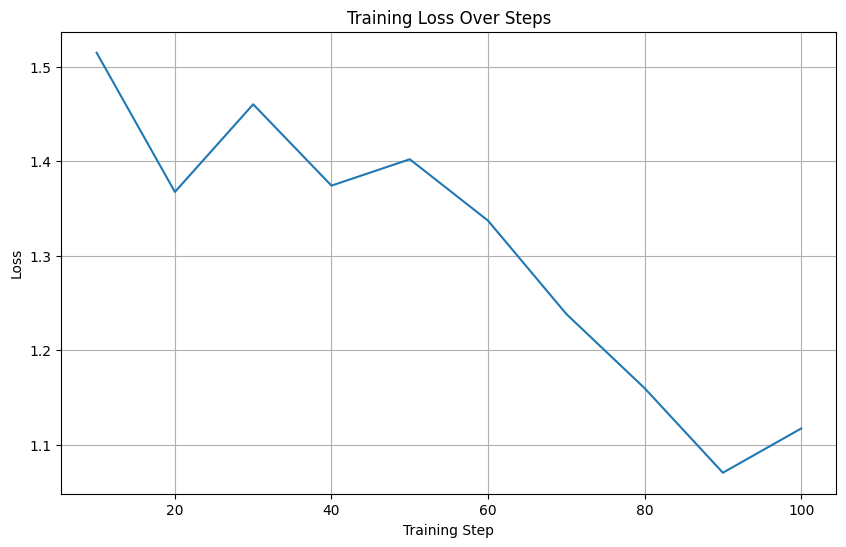

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract training history from the trainer
log_history = trainer.state.log_history

# Convert to a DataFrame for easier plotting
logs_df = pd.DataFrame(log_history)

# Filter for training loss (usually denoted as 'loss' or 'train_loss')
# 'loss' is typically the training loss reported at each logging step
# 'eval_loss' would be present if evaluation_strategy was set to 'steps' or 'epoch'

train_loss_data = logs_df.dropna(subset=['loss'])

if not train_loss_data.empty:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=train_loss_data, x='step', y='loss')
    plt.title('Training Loss Over Steps')
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()
else:
    print("No training loss data found in the trainer's log history.")

# If evaluation_strategy was enabled and had eval_loss:
# eval_loss_data = logs_df.dropna(subset=['eval_loss'])
# if not eval_loss_data.empty:
#     plt.figure(figsize=(10, 6))
#     sns.lineplot(data=eval_loss_data, x='step', y='eval_loss')
#     plt.title('Validation Loss Over Steps')
#     plt.xlabel('Training Step')
#     plt.ylabel('Validation Loss')
#     plt.grid(True)
#     plt.show()
# else:
#     print("No validation loss data found in the trainer's log history.")

#Why do we fine-tune a model?

We fine-tune a pre-trained model primarily to adapt it to a specific task or dataset that differs from the one it was originally trained on.

Large Language Models (LLMs) like (Mistral-7B) are typically trained on vast amounts of general text data, making them proficient at understanding and generating human-like text.

However, they might lack specialized knowledge, jargon, or stylistic preferences required for a particular domain (e.g., medical texts, legal documents, customer support) or a specific application (e.g., summarization, translation, specific question answering).

Fine-tuning allows the model to learn these specific nuances while retaining the broad understanding it gained during its initial pre-training, effectively tailoring its capabilities to your exact needs.

#Advantages and Disadvantages of Fine-tuning a Model:

###Advantages:

Improved Performance on Specific Tasks: Fine-tuning makes the model highly effective for your target task or domain, often outperforming general-purpose models.

Less Data Required (vs. Training from Scratch): You don't need a massive dataset like the one used for initial pre-training. A relatively smaller, high-quality, task-specific dataset is often sufficient.

Faster Training: Since the model already has a strong foundation, fine-tuning converges much faster than training a model from scratch.


Cost-Effective: Less data and faster training translate to lower computational costs.


Leverages Pre-trained Knowledge: The model benefits from the vast general knowledge acquired during pre-training, making it robust and less prone to overfitting on small datasets.


Transfer Learning: It's an excellent example of transfer learning, where knowledge gained from one task (general language understanding) is transferred to improve performance on another (specific domain task).


###Disadvantages:

Requires Labeled Data: You still need a labeled dataset specific to your task, which can sometimes be expensive or time-consuming to create.


Catastrophic Forgetting: If fine-tuned improperly or on very different data, the model might 'forget' some of its general knowledge. Techniques like LoRA (which you're using) help mitigate this by not directly modifying the original weights.


Computational Resources: While less demanding than training from scratch, fine-tuning LLMs still requires significant computational resources (GPUs, VRAM), though methods like QLoRA reduce this burden.


Hyperparameter Tuning: Finding the optimal hyperparameters (like the LORA_R, LORA_ALPHA, LEARNING_RATE, BATCH_SIZE you configured) can still require experimentation.


Model Bias: If the fine-tuning dataset contains biases, the model can learn and even amplify these biases.


###How can I apply my fine-tuned model to a dataset?

After fine-tuning with QLoRA and saving the adapter weights (as you've done in your notebook), you typically apply the model in a few steps:

Load the Base Model: Load the original pre-trained model (e.g., mistralai/Mistral-7B-v0.1) in its quantized form.


Load the PEFT Adapter: Load your saved LoRA adapter weights (./fine_tuned_llm) and attach them to the base model.


Load the Tokenizer: Load the tokenizer you used during fine-tuning (also saved to ./fine_tuned_llm).


Merge and Save (Optional but Recommended for Deployment): For easier deployment, you can merge the LoRA adapter weights back into the base model. This creates a single, larger model that behaves like the fine-tuned version without needing the PEFT library at inference time. This merged model can then be saved as a standard Hugging Face model.


Inference: Once the fine-tuned model (or the merged model) is loaded, you can use it to generate responses for new inputs from your dataset. You'll typically tokenize your input, pass it to the model for generation, and then decode the output tokens back into human-readable text.

### Download the fine_tuned_llm folder

In [16]:
import os
from google.colab import files

# Define the output directory
OUTPUT_DIR = "./fine_tuned_llm"

# Create a zip archive of the folder
zip_filename = f"{os.path.basename(OUTPUT_DIR)}.zip"
!zip -r "{zip_filename}" "{OUTPUT_DIR}"

# Download the zip file to your local machine
files.download(zip_filename)


  adding: fine_tuned_llm/ (stored 0%)
  adding: fine_tuned_llm/tokenizer.json (deflated 85%)
  adding: fine_tuned_llm/checkpoint-50/ (stored 0%)
  adding: fine_tuned_llm/checkpoint-50/tokenizer.json (deflated 85%)
  adding: fine_tuned_llm/checkpoint-50/scheduler.pt (deflated 62%)
  adding: fine_tuned_llm/checkpoint-50/tokenizer_config.json (deflated 49%)
  adding: fine_tuned_llm/checkpoint-50/optimizer.pt (deflated 12%)
  adding: fine_tuned_llm/checkpoint-50/adapter_model.safetensors (deflated 21%)
  adding: fine_tuned_llm/checkpoint-50/trainer_state.json (deflated 66%)
  adding: fine_tuned_llm/checkpoint-50/rng_state.pth (deflated 26%)
  adding: fine_tuned_llm/checkpoint-50/README.md (deflated 65%)
  adding: fine_tuned_llm/checkpoint-50/training_args.bin (deflated 53%)
  adding: fine_tuned_llm/checkpoint-50/adapter_config.json (deflated 60%)
  adding: fine_tuned_llm/tokenizer_config.json (deflated 49%)
  adding: fine_tuned_llm/adapter_model.safetensors (deflated 21%)
  adding: fine_tu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Alternatively, save to Google Drive for permanent storage

If you prefer to save it directly to Google Drive, you can mount your Drive and copy the folder there. This ensures persistence even if your Colab session ends.

In [17]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define the output directory and the destination path in Google Drive
OUTPUT_DIR = "./fine_tuned_llm"
DRIVE_PATH = "/content/drive/MyDrive/FineTunedModels"

# Create the destination directory in Drive if it doesn't exist
os.makedirs(DRIVE_PATH, exist_ok=True)

# Copy the fine_tuned_llm folder to Google Drive
shutil.copytree(OUTPUT_DIR, os.path.join(DRIVE_PATH, os.path.basename(OUTPUT_DIR)), dirs_exist_ok=True)

print(f"Folder '{OUTPUT_DIR}' successfully copied to '{DRIVE_PATH}'")


Mounted at /content/drive
Folder './fine_tuned_llm' successfully copied to '/content/drive/MyDrive/FineTunedModels'
